<a href="https://colab.research.google.com/github/manasamorthad/DeepLearning/blob/main/week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**9.Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.**

Learning Rate: 0.01, Final Loss: 0.240571
Learning Rate: 0.05, Final Loss: 0.012541
Learning Rate: 0.1, Final Loss: 0.002546
Learning Rate: 0.5, Final Loss: 0.000293
Learning Rate: 1.0, Final Loss: 0.000135


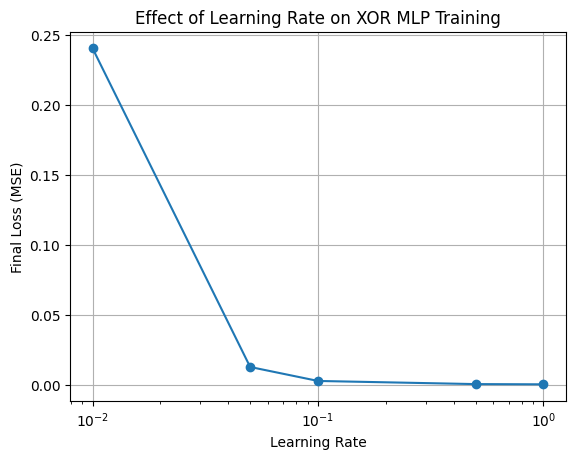

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []

epochs = 10000

for lr in learning_rates:

    np.random.seed(42)

    W1 = np.random.rand(2, 2)
    b1 = np.random.rand(1, 2)

    W2 = np.random.rand(2, 1)
    b2 = np.random.rand(1, 1)

    for epoch in range(epochs):

        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W2) + b2
        y_pred = sigmoid(final_input)

        error = y - y_pred
        loss = np.mean(error ** 2)

        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr

        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

**10.Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.**

In [2]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

np.random.seed(42)

W1 = np.random.rand(2, 2)
b1 = np.random.rand(1, 2)

W2 = np.random.rand(2, 1)
b2 = np.random.rand(1, 1)

learning_rate = 0.1
epochs = 10000

for epoch in range(epochs):

    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    y_pred = sigmoid(final_input)

    error = y - y_pred
    loss = np.mean(error ** 2)

    d_output = error * sigmoid_derivative(y_pred)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("\nXOR Predictions after Training:")
for i in range(len(X)):
    print(X[i], "->", round(y_pred[i][0]))

Epoch 0, Loss: 0.3247
Epoch 1000, Loss: 0.2406
Epoch 2000, Loss: 0.1960
Epoch 3000, Loss: 0.1207
Epoch 4000, Loss: 0.0305
Epoch 5000, Loss: 0.0125
Epoch 6000, Loss: 0.0074
Epoch 7000, Loss: 0.0051
Epoch 8000, Loss: 0.0038
Epoch 9000, Loss: 0.0031

XOR Predictions after Training:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


**11.Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class)**

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

for lr in learning_rates:

    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("Learning Rate:", lr)
    print("Accuracy:", acc)
    print("Iterations used:", model.n_iter_)
    print()

Learning Rate: 0.0001
Accuracy: 0.9
Iterations used: 6

Learning Rate: 0.001
Accuracy: 0.9
Iterations used: 6

Learning Rate: 0.01
Accuracy: 0.9333333333333333
Iterations used: 9

Learning Rate: 0.1
Accuracy: 0.9333333333333333
Iterations used: 9

Learning Rate: 1.0
Accuracy: 0.9333333333333333
Iterations used: 9



**13.Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.54125506
Iteration 2, loss = 0.26261541
Iteration 3, loss = 0.21334693
Iteration 4, loss = 0.18041799
Iteration 5, loss = 0.15521071
Iteration 6, loss = 0.13713162
Iteration 7, loss = 0.12167082
Iteration 8, loss = 0.10957409
Iteration 9, loss = 0.09910434
Iteration 10, loss = 0.09005121
Iteration 11, loss = 0.08238981
Iteration 12, loss = 0.07590413
Iteration 13, loss = 0.06990400
Iteration 14, loss = 0.06552830
Iteration 15, loss = 0.06068202
Iteration 16, loss = 0.05696692
Iteration 17, loss = 0.05327114
Iteration 18, loss = 0.04979526
Iteration 19, loss = 0.04618848
Iteration 20, loss = 0.04420099
Iteration 21, loss = 0.04145133
Iteration 22, loss = 0.03863193
Iteration 23, loss = 0.03670778
Iteration 24, loss = 0.03395817
Iteration 25, loss = 0.03256089
Iteration 26, loss = 0.03003133
Iteration 27, loss = 0.02852477
Iteration 28, loss = 0.02670121
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.9996666666666667
Testing set score: 0.974
Predicted value: 6
Actual value: 6


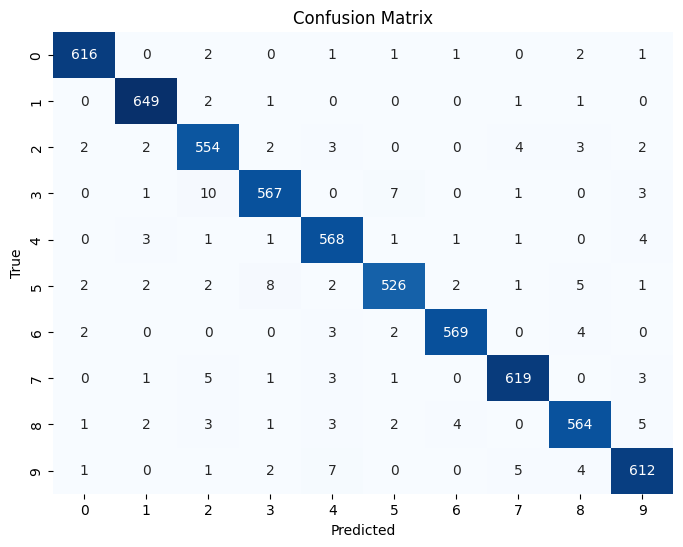

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794427
Iteration 5, loss = 0.42552618
Iteration 6, loss = 0.42483506
Iteration 7, loss = 0.43145128
Iteration 8, loss = 0.42965931
Iteration 9, loss = 0.48689868
Iteration 10, loss = 0.43131150
Iteration 11, loss = 0.44657347
Iteration 12, loss = 0.44554835
Iteration 13, loss = 0.43811670
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8982037037037037
Testing set score (MLP2): 0.8838333333333334


In [4]:
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0

X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full  = X_test_full.reshape(-1, 28*28)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1
)

mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

index = 346
test_digit = X_test[index].reshape(1, 784)

prediction = mlp.predict(test_digit)[0]

print("Predicted value:", prediction)
print("Actual value:", y_test[index])

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = mlp.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)

mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))